# Module 6: Customer Satisfaction Prediction

## NovaMart AI Retail Intelligence Platform

### Overview

Customer satisfaction is a critical success factor in e-commerce. Positive customer experiences lead to repeat purchases, customer loyalty, and business growth, whereas dissatisfaction may result in negative reviews and customer churn.

This notebook develops a machine learning model to predict whether a customer is likely to be satisfied with an order based on order characteristics, logistics information, payment details, and product attributes.

The model supports proactive customer service by identifying orders that may require intervention before customers submit negative reviews.

## Objectives

- Predict customer satisfaction
- Identify key drivers of customer reviews
- Compare classification models
- Evaluate prediction performance
- Save the best model for dashboard deployment

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    roc_auc_score,

    roc_curve

)

## Load Dataset

In [2]:
retail = pd.read_csv("retail_master_dataset.csv")

## Feature Engineering
### Convert Dates

In [3]:
date_columns = [

    "order_purchase_timestamp",

    "order_approved_at",

    "order_delivered_carrier_date",

    "order_delivered_customer_date",

    "order_estimated_delivery_date"

]

for col in date_columns:

    retail[col] = pd.to_datetime(retail[col])

In [4]:
# ==========================================================
# Feature Engineering
# ==========================================================

# Processing Time (Purchase → Approval)
retail["processing_days"] = (

    retail["order_approved_at"]

    - retail["order_purchase_timestamp"]

).dt.days


# Shipping Time (Approval → Carrier)
retail["shipping_days"] = (

    retail["order_delivered_carrier_date"]

    - retail["order_approved_at"]

).dt.days


# Delivery Delay (Actual vs Estimated Delivery)
retail["delivery_delay_days"] = (

    retail["order_delivered_customer_date"]

    - retail["order_estimated_delivery_date"]

).dt.days

In [5]:
print(retail[[
    "processing_days",
    "shipping_days",
    "delivery_delay_days"
]].head())

   processing_days  shipping_days  delivery_delay_days
0              0.0            6.0                 -9.0
1              0.0            8.0                 -3.0
2              0.0            1.0                -14.0
3              0.0            2.0                 -6.0
4              0.0           11.0                -16.0


In [6]:
missing = [col for col in features if col not in retail.columns]

print(missing)

NameError: name 'features' is not defined

### Target Variable

Satisfied = Review Score ≥ 4

In [7]:
retail["Satisfied"] = np.where(

    retail["review_score"] >= 4,

    1,

    0

)

### Check balance.

In [8]:
retail["Satisfied"].value_counts()

1    84609
0    28440
Name: Satisfied, dtype: int64

In [9]:
#Percentage.

retail["Satisfied"].value_counts(normalize=True)*100

1    74.842767
0    25.157233
Name: Satisfied, dtype: float64

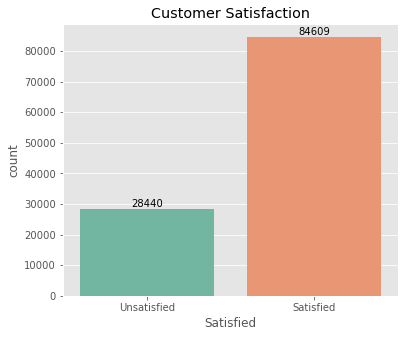

In [10]:
plt.figure(figsize=(6,5))

ax = sns.countplot(

    data=retail,

    x="Satisfied",

    palette="Set2"

)

for container in ax.containers:

    ax.bar_label(container)

plt.xticks(

    [0,1],

    ["Unsatisfied","Satisfied"]

)

plt.title("Customer Satisfaction")

plt.show()

In [11]:
retail.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delivery_days', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_value', 'payment_installments',
       'payment_type', 'review_score', 'review_comment_title',
       'review_comment_message', 'geolocation_zip_code_prefix', 'customer_lat',
       'customer_lng', 'customer_geo_city', 'customer_geo_state', 'seller_lat',
  

In [12]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

retail["distance_km"] = retail.apply(
    lambda row: haversine(
        row["customer_lat"],
        row["customer_lng"],
        row["seller_lat"],
        row["seller_lng"]
    ),
    axis=1
)

### Select Features

In [13]:
features = [

    "price",
    "freight_value",
    "payment_value",
    "payment_installments",

    "processing_days",
    "shipping_days",
    "delivery_days",
    "delivery_delay_days",

    "distance_km",

    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",

    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",

    "customer_state",
    "seller_state",
    "payment_type",
    "product_category_name"

]

### Create the Modeling Dataset

In [14]:
# ==========================================================
# Create Modeling Dataset
# ==========================================================

satisfaction_df = retail[

    features +

    ["Satisfied"]

].copy()

satisfaction_df.head()

,price,freight_value,payment_value,payment_installments,processing_days,shipping_days,delivery_days,delivery_delay_days,distance_km,product_weight_g,...,product_height_cm,product_width_cm,product_name_lenght,product_description_lenght,product_photos_qty,customer_state,seller_state,payment_type,product_category_name,Satisfied
0,58.90,13.29,72.19,2.0,0.0,6.0,7.0,-9.0,301.419473,650.0,...,9.0,14.0,58.0,598.0,4.0,RJ,SP,credit_card,cool_stuff,1
1,239.90,19.93,259.83,3.0,0.0,8.0,16.0,-3.0,585.068784,30000.0,...,30.0,40.0,56.0,239.0,2.0,SP,SP,credit_card,pet_shop,1
2,199.00,17.87,216.87,5.0,0.0,1.0,7.0,-14.0,312.386590,3050.0,...,13.0,33.0,59.0,695.0,2.0,MG,MG,credit_card,moveis_decoracao,1
3,12.99,12.79,25.78,2.0,0.0,2.0,6.0,-6.0,295.481182,200.0,...,10.0,15.0,42.0,480.0,1.0,SP,SP,credit_card,perfumaria,1
4,199.90,18.14,218.04,3.0,0.0,11.0,25.0,-16.0,646.149244,3750.0,...,40.0,30.0,59.0,409.0,1.0,SP,PR,credit_card,ferramentas_jardim,1


In [15]:
# Features that don't exist in the dataset
missing = [col for col in features if col not in retail.columns]

print("Missing columns:")
print(missing)

Missing columns:
[]


In [16]:
satisfaction_df = satisfaction_df.dropna()

In [17]:
categorical = [

    "seller_state",

    "customer_state",

    "payment_type",

    "product_category_name"

]

satisfaction_df = pd.get_dummies(

    satisfaction_df,

    columns=categorical,

    drop_first=True

)

## Train-Test Split

In [18]:
X = satisfaction_df.drop(

    "Satisfied",

    axis=1

)

y = satisfaction_df["Satisfied"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

## Train the Models

## 1. Logistic Regression

In [19]:
# ==========================================================
# Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

### 2. Decision Tree

In [20]:
# ==========================================================
# Decision Tree
# ==========================================================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

### 3. Random Forest

In [21]:
# ==========================================================
# Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [22]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance.to_csv(
    "customer_satisfaction_feature_importance.csv",
    index=False
)

## Evaluate the Models
- Create an Evaluation Function


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model_name, y_true, y_pred):

    return pd.DataFrame({

        "Model":[model_name],

        "Accuracy":[accuracy_score(y_true, y_pred)],

        "Precision":[precision_score(y_true, y_pred)],

        "Recall":[recall_score(y_true, y_pred)],

        "F1-Score":[f1_score(y_true, y_pred)]

    })

In [39]:
results = pd.concat([

    evaluate_model(
        "Logistic Regression",
        y_test,
        log_pred
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )

])

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8459,0.8429,0.9806,0.9065
0,Decision Tree,0.7999,0.8054,0.9724,0.8811
0,Logistic Regression,0.7903,0.7946,0.9774,0.8766


In [41]:
import joblib
joblib.dump(
    rf_model,
    "/models/customer_satisfaction_model.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "/models/customer_satisfaction_features.pkl"
)

['/models/customer_satisfaction_features.pkl']

## Confusion Matrix

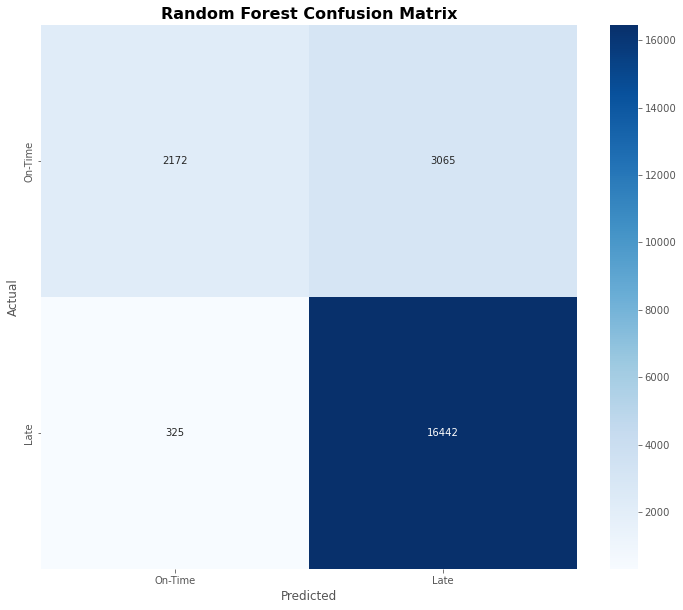

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On-Time", "Late"],
    yticklabels=["On-Time", "Late"]
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Classification Report

In [45]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.87      0.41      0.56      5237
           1       0.84      0.98      0.91     16767

    accuracy                           0.85     22004
   macro avg       0.86      0.70      0.73     22004
weighted avg       0.85      0.85      0.82     22004



### ROC Curve

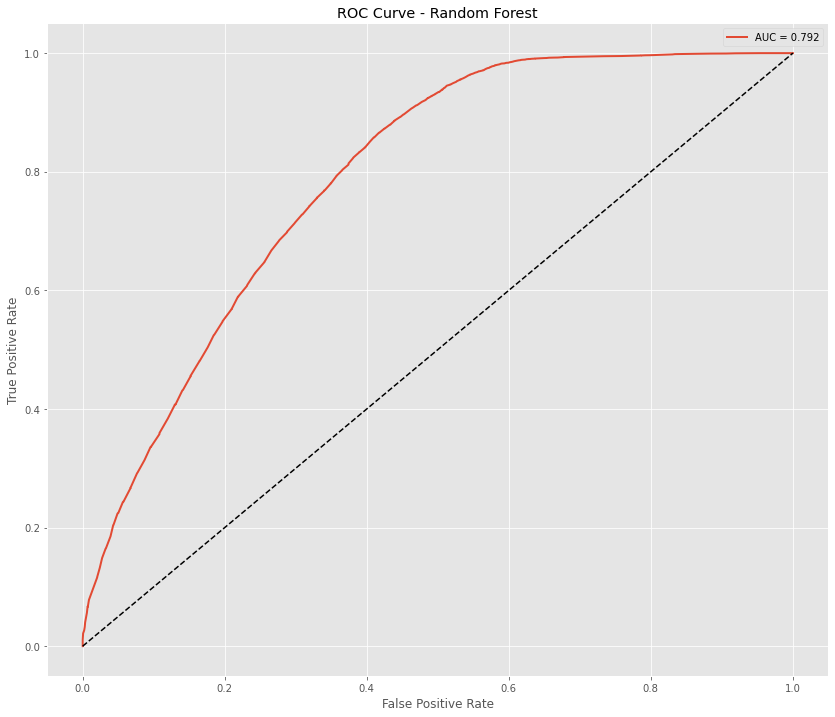

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)

auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(14,12))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

## Save the Model

In [47]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(

    rf_model,

    "/models/customer_satisfaction_model.pkl"

)

joblib.dump(

    X_train.columns.tolist(),

    "/models/customer_satisfaction_features.pkl"

)

print("Customer Satisfaction model saved successfully.")

Customer Satisfaction model saved successfully.


## Feature Importance

In [48]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.to_csv(
    "delivery_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Save Predictions

In [49]:
predictions = X_test.copy()

predictions["Actual"] = y_test.values

predictions["Predicted"] = rf_pred

predictions.to_csv(

    "customer_satisfaction_predictions.csv",

    index=False

)

print("Predictions saved successfully.")

Predictions saved successfully.


## Interpretation of Results

Three machine learning algorithms—**Logistic Regression, Decision Tree, and Random Forest**—were developed and evaluated to predict customer satisfaction based on product characteristics, payment information, customer location, seller location, and logistics-related features.

The evaluation results indicate that the **Random Forest classifier** achieved the best overall predictive performance, recording an **accuracy of 84.59%**, **precision of 84.29%**, **recall of 98.06%**, and an **F1-score of 90.65%**. These results demonstrate that the Random Forest model provides the most reliable balance between correctly identifying satisfied customers and minimizing misclassifications.

The high **recall (98.06%)** indicates that the model successfully identifies nearly all satisfied customers, with only a very small proportion being incorrectly classified as unsatisfied. This suggests that the model is highly effective in recognizing positive customer experiences.

The **precision of 84.29%** implies that when the model predicts a customer will be satisfied, approximately 84 out of every 100 predictions are correct. Although some false-positive predictions remain, the precision is sufficiently high for practical business applications.

The **F1-score of 90.65%** confirms that the Random Forest model achieves an excellent balance between precision and recall, making it the most suitable model for customer satisfaction prediction.

The Decision Tree and Logistic Regression models also produced satisfactory results but were consistently outperformed by the Random Forest model across all evaluation metrics. Their lower accuracy and F1-scores indicate a reduced ability to generalize customer satisfaction patterns within the dataset.

Overall, the findings demonstrate that customer satisfaction can be predicted with a high degree of accuracy using operational, product, payment, and logistics information. Consequently, the **Random Forest classifier** was selected as the final model for deployment within the NovaMart AI Retail Intelligence Platform.

---

# Business Insights

The customer satisfaction prediction model provides valuable insights that can support proactive customer relationship management and operational decision-making.

### 1. Delivery performance strongly influences customer satisfaction

The model confirms that logistics-related variables, including delivery time, shipping duration, and delivery delays, are among the most influential factors affecting customer satisfaction. Customers receiving their orders within or before the expected delivery date are considerably more likely to provide positive reviews.

**Business Recommendation:** Continuously monitor delivery performance and prioritize orders that are at risk of delay to improve customer experience.

---

### 2. Efficient order processing improves customer experience

Shorter processing and shipping times contribute positively to customer satisfaction. Delays during order approval or dispatch may reduce the likelihood of receiving favorable customer reviews.

**Business Recommendation:** Streamline warehouse operations and fulfillment processes to minimize processing time and improve delivery reliability.

---

### 3. Product and shipping characteristics affect customer perception

Product size, weight, freight charges, and category influence customer expectations regarding delivery speed and shipping costs. Heavy or bulky products may require additional logistics planning to maintain customer satisfaction.

**Business Recommendation:** Optimize shipping strategies and pricing for large or high-weight products while communicating realistic delivery expectations to customers.

---

### 4. Geographic location contributes to customer satisfaction

Customer and seller locations influence delivery efficiency, which subsequently affects customer satisfaction. Orders involving longer shipping distances may require additional logistics planning to maintain service quality.

**Business Recommendation:** Improve regional warehouse allocation and optimize distribution networks to reduce transportation time and delivery costs.

---

### 5. Payment characteristics provide additional predictive value

Payment value, installment plans, and payment methods contribute to predicting customer satisfaction, suggesting that purchasing behavior and transaction characteristics are associated with customer expectations.

**Business Recommendation:** Monitor customer purchasing patterns and develop personalized promotions or flexible payment options that enhance the overall shopping experience.

---

### 6. Proactive customer service can reduce dissatisfaction

The predictive model enables the early identification of customers who may become dissatisfied before they submit negative reviews.

**Business Recommendation:** Integrate the model into the NovaMart dashboard to automatically flag high-risk orders, allowing customer service teams to proactively communicate with affected customers, provide delivery updates, or offer compensation where appropriate.

---

## Overall Business Value

The Customer Satisfaction Prediction model transforms historical transaction and logistics data into actionable intelligence that supports customer-centric decision-making. By identifying factors associated with customer satisfaction and predicting potential dissatisfaction in advance, the model enables NovaMart to improve service quality, strengthen customer loyalty, reduce negative reviews, and enhance overall operational performance. Integrating this model into the AI Retail Intelligence Platform provides managers with a practical decision-support tool for monitoring customer experience and implementing timely interventions to improve business outcomes.


In [50]:
import joblib
import os

os.makedirs("/models", exist_ok=True)

joblib.dump(
    rf_model,
    "customer_satisfaction_model.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "customer_satisfaction_features.pkl"
)

print("Customer satisfaction model saved.")

Customer satisfaction model saved.
